In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


## Simulaatio

In [4]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

In [5]:
def sim_pulse(f_d,f_supp,A,evolution,dim,f_rabi,K=20,t_ramp=5,verbose=False,p=1):
    T_floquet = 2*np.pi/(f_d) #Floquet-jakson pituus
    dt = T_floquet/K #Diskretoidaan aika-avaruus siten, että Floquet-jakson pituus on K aikapistettä

    t_gap=np.pi/(f_supp)
    t_ramp_new=t_ramp-t_gap/2

    phi=t_gap*f_d
    
    N_edge1 = int((t_ramp_new*2+t_gap/2)/dt)
    N_edge2 = int((t_ramp_new*2-t_gap/2)/dt)

    N_pulse=int(2*np.pi/(f_rabi*dt)) #Määritellään pulssin pituus arvatun Rabi-taajuuden perusteella

    #Kokonainen pulssi rampin aikakehityksen sekä Floquet-operaattorin laskemista varten
    pulse1 = pulses.Pulse(f_d,f_supp,[pulses.gaussian(t_ramp_new*2-t_gap/2,t_ramp_new/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new/2)],[N_edge2,N_pulse,N_edge1],time_unit=dt,offset_input=-phi/2)
    pulse2 = pulses.Pulse(f_d,f_supp,[pulses.gaussian(t_ramp_new*2+t_gap/2,t_ramp_new/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new/2)],[N_edge1,N_pulse,N_edge2],time_unit=dt,offset_input=phi/2)

    combined_pulse = pulse1.raw + pulse2.raw
    m = 2*np.abs(np.cos(phi/2))

    if verbose:
        plt.figure()
        plt.plot(pulse1.time_vals,combined_pulse/m)
        plt.plot(pulse1.time_vals,(pulse1.envelope + pulse2.envelope)/2)
        plt.xlabel("Aika (ms)")
        plt.xlim([5,10])
        plt.ylabel("Normalisoitu amplitudi")
        plt.title("Yhdistetty pulssi")
        plt.show()

    U_floquet=evolution.U_floquet(A*combined_pulse[N_edge1:N_edge1+K]/m,dt)
    U_floquet=np.linalg.matrix_power(U_floquet,p)

    #Alustetaan kubitin tila perustilaan
    psi_eig_accum = np.zeros(dim, dtype=complex)
    psi_eig_accum[0] = 1

    #Lopulliset todennäköisyydet eripituisten pulssien jälkeen
    last_vals=[]

    for i in range(0, N_edge1): #Aikakehitys nousevalle rampille
        psi_eig_accum = evolution.U(A*combined_pulse[i]/m, dt) @ psi_eig_accum

    #Simuloitujen pulssien määrä/K koska jokainen simulaatio edistää tilaa yhden Floquet-jakson (K*dt)
    N_sim=int(N_pulse/(K*p))

    #Simulaatio pulsseille
    for k in range(0,N_sim):
        psi_eig = psi_eig_accum

        #Laskevan rampin simulaatio
        pulse1 = pulses.Pulse(f_d,f_supp,[pulses.gaussian(t_ramp*2-t_gap/2,t_ramp_new/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new/2)],[N_edge2,K*p*k,N_edge1],time_unit=dt,offset_input=-phi/2)
        pulse2 = pulses.Pulse(f_d,f_supp,[pulses.gaussian(t_ramp*2+t_gap/2,t_ramp_new/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new/2)],[N_edge1,K*p*k,N_edge2],time_unit=dt,offset_input=phi/2)
        combined_pulse = pulse1.raw + pulse2.raw

        remainder = len(combined_pulse)-N_edge1-K*p*k

        for i in range(0, remainder): #Aikakehitys
            psi_eig = evolution_eigenbasis.U(A*combined_pulse[N_edge1+K*p*k+i]/m, dt) @ psi_eig
        last_vals.append(np.abs(psi_eig)**2)
        psi_eig_accum = U_floquet @ psi_eig_accum #Kehitetään kubitin tilaa yhdellä Floquet-jaksolla


    #e- ja f-tasojen lopulliset todennäköisyydet
    e_vals = np.array([a[1] for a in last_vals])
    f_vals = np.array([a[2] for a in last_vals])

    #e-tason suurin todennäköisyys
    excited_max=max(e_vals)
    #f-tason suurin todennäköisyys pulssille, jolla e-taso saavuttaa suurimman arvonsa
    f_max=max(f_vals)

    #Simuloitujen pulssien pituudet, plottausta varten
    pulse_times=np.arange(0,N_pulse)*K*p*dt + 2*t_ramp

    #Pulssin pituus määritettynä maksimiarvon sijainnin perusteella
    index = np.argmax(e_vals)
    T_pulse = pulse_times[index]
    
    return (excited_max,f_max,T_pulse,last_vals,pulse_times)

def find_params(f_d,A,evolution,f_rabi,AC_stark,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]

    for i in range(min_range,max_range):
        delta=AC_stark+i/scale #AC-stark siirtymä
        AC_stark_vals.append(delta)

        if A < 0.09:
            sim_vals = sim_pulse(f_d+delta,f_ef,A,evolution,dim,f_rabi,t_ramp=5,p=10)
        else:
            sim_vals = sim_pulse(f_d+delta,f_ef,A,evolution,dim,f_rabi,t_ramp=5,p=1)

        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=ω_ef-ω_suppressed (GHz)")
    plt.ylabel("Suurin e-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    AC_stark=AC_stark_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(AC_stark,pi_pulse,[e_max,f_max],max_e_vals)

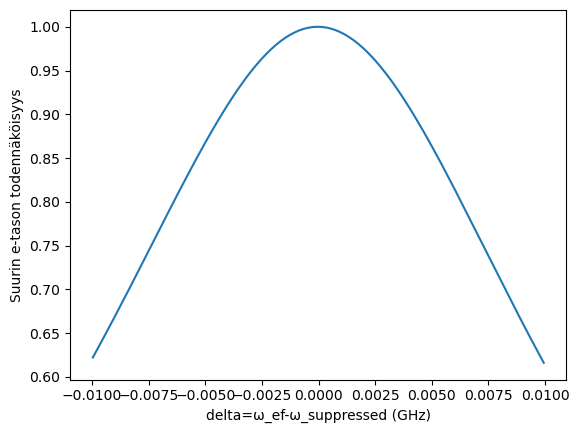

Amplitudi (GHz): 0.012744300694748545
AC-stark siirtymä (GHz): -6.012809935183704e-05
E-tason suurin todennäköisyys: 0.9999953223737541
Pulssin pituus (ns): 251.57999227525542
Rabi-taajuus (fourier):  0.0018932189704428453


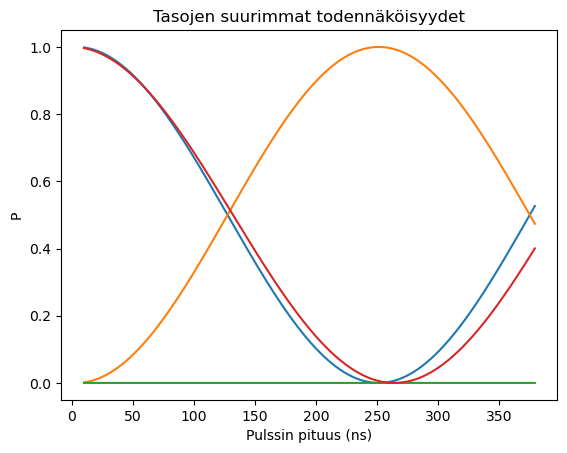

---------------------------------------------


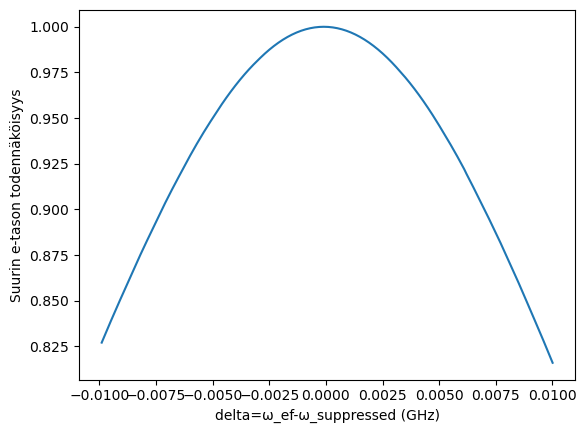

Amplitudi (GHz): 0.02146408538062913
AC-stark siirtymä (GHz): -9.501932447282692e-05
E-tason suurin todennäköisyys: 0.9999999886742346
Pulssin pituus (ns): 150.51100417886548
Rabi-taajuus (fourier):  0.0031884518825393707


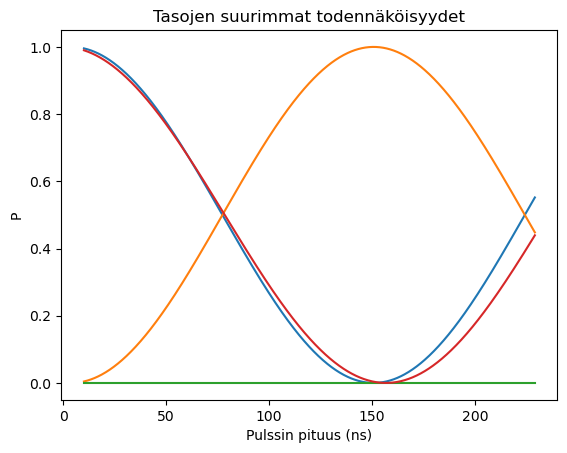

---------------------------------------------


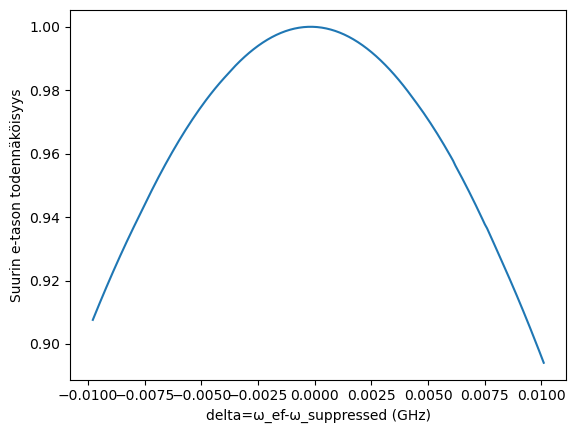

Amplitudi (GHz): 0.030183870066509716
AC-stark siirtymä (GHz): -0.00019532999306231692
E-tason suurin todennäköisyys: 0.9999997221285672
Pulssin pituus (ns): 108.60460151978367
Rabi-taajuus (fourier):  0.004483852946679996


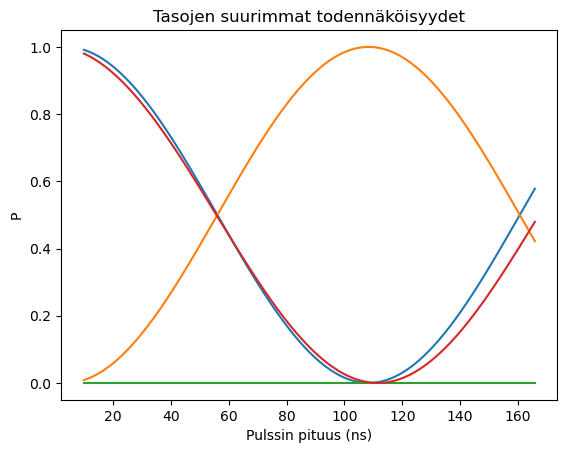

---------------------------------------------


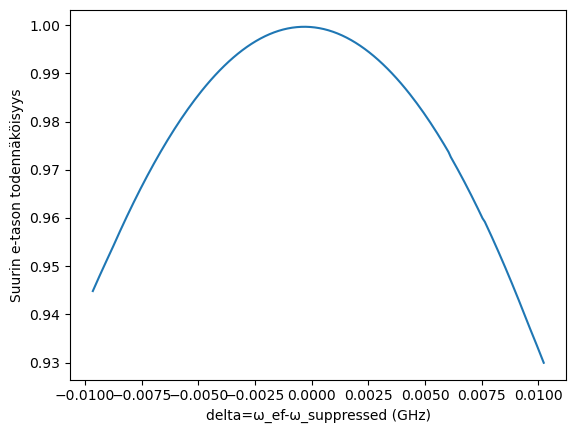

Amplitudi (GHz): 0.0389036547523903
AC-stark siirtymä (GHz): -0.00036106010512030706
E-tason suurin todennäköisyys: 0.9999976622456761
Pulssin pituus (ns): 83.95393200134825
Rabi-taajuus (fourier):  0.005779779375932932


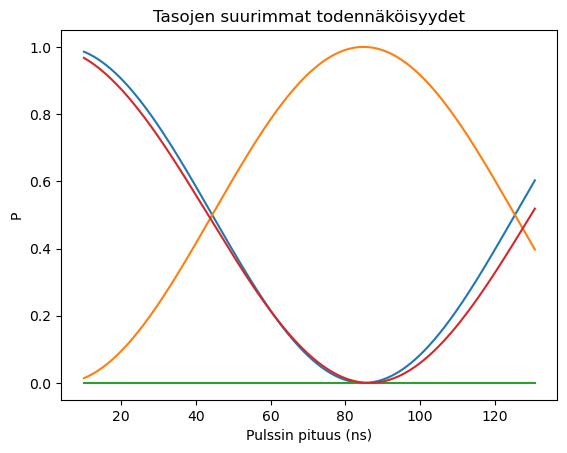

---------------------------------------------


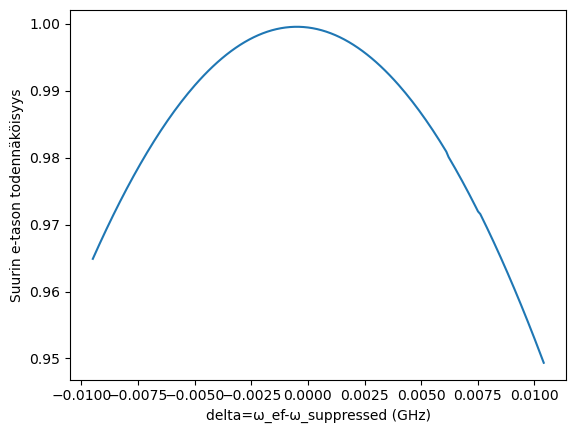

Amplitudi (GHz): 0.04762343943827089
AC-stark siirtymä (GHz): -0.0004922096606467974
E-tason suurin todennäköisyys: 0.9999993825431176
Pulssin pituus (ns): 69.16345002618107
Rabi-taajuus (fourier):  0.007074217728514737


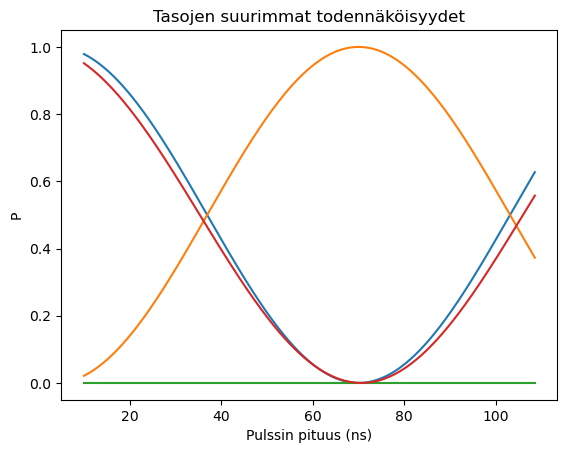

---------------------------------------------


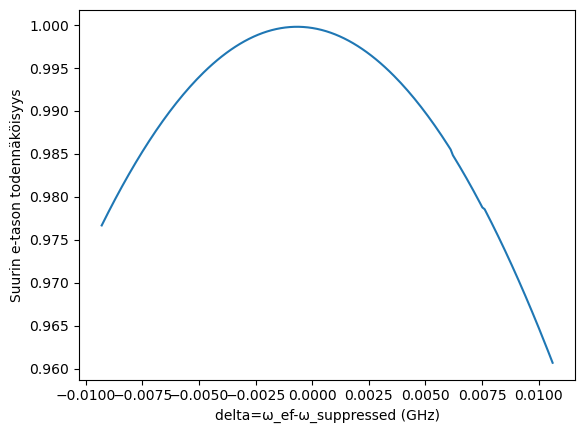

Amplitudi (GHz): 0.05634322412415147
AC-stark siirtymä (GHz): -0.0006887786596417877
E-tason suurin todennäköisyys: 0.9999990112597176
Pulssin pituus (ns): 59.30325525761555
Rabi-taajuus (fourier):  0.008371371157949052


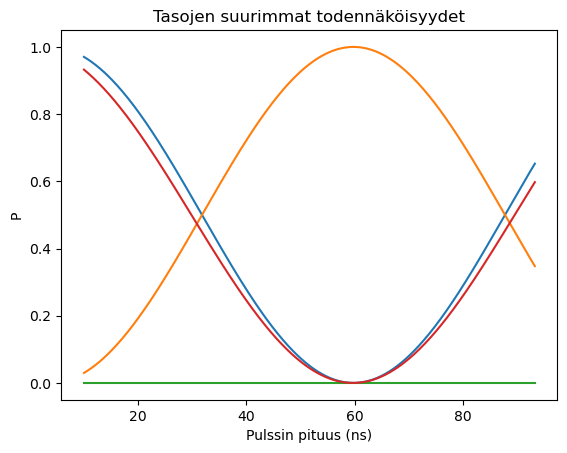

---------------------------------------------


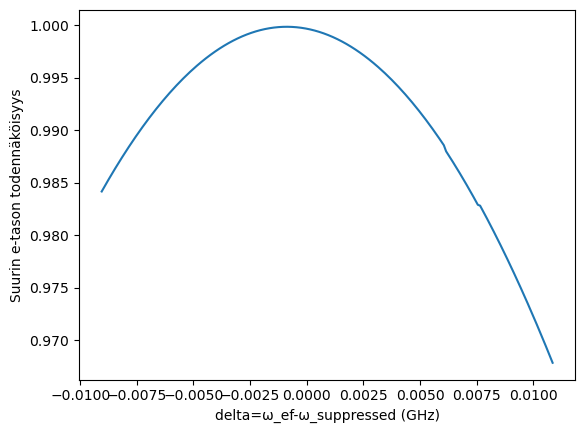

Amplitudi (GHz): 0.06506300881003205
AC-stark siirtymä (GHz): -0.0008507671021052784
E-tason suurin todennäköisyys: 0.9999998613906432
Pulssin pituus (ns): 51.908033315501754
Rabi-taajuus (fourier):  0.009664911674245711


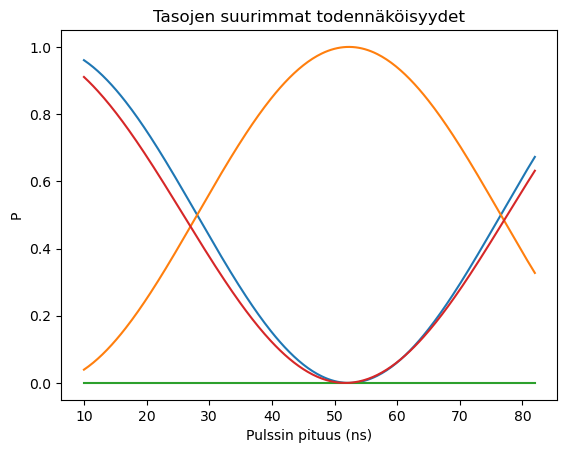

---------------------------------------------


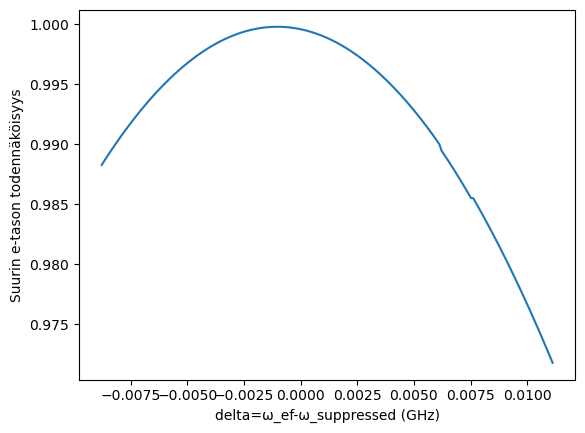

Amplitudi (GHz): 0.07378279349591264
AC-stark siirtymä (GHz): -0.0010781749880372689
E-tason suurin todennäköisyys: 0.9999996801587152
Pulssin pituus (ns): 46.97800638158603
Rabi-taajuus (fourier):  0.010963419747996101


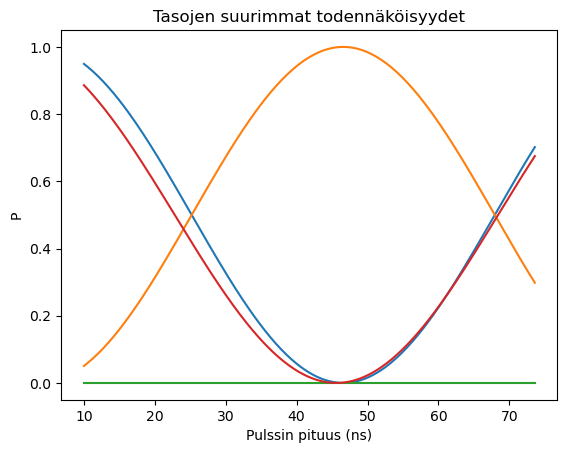

---------------------------------------------


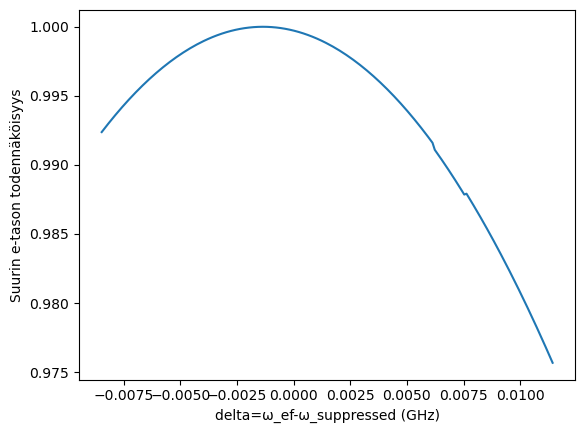

Amplitudi (GHz): 0.08250257818179323
AC-stark siirtymä (GHz): -0.0013710023174377593
E-tason suurin todennäköisyys: 0.9999999218463151
Pulssin pituus (ns): 42.047973731355775
Rabi-taajuus (fourier):  0.012260332863942692


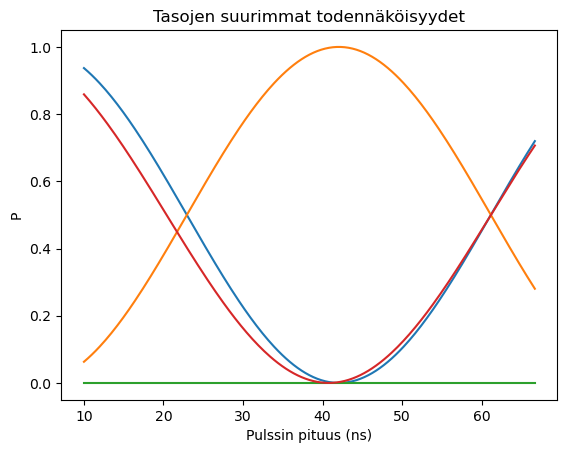

---------------------------------------------


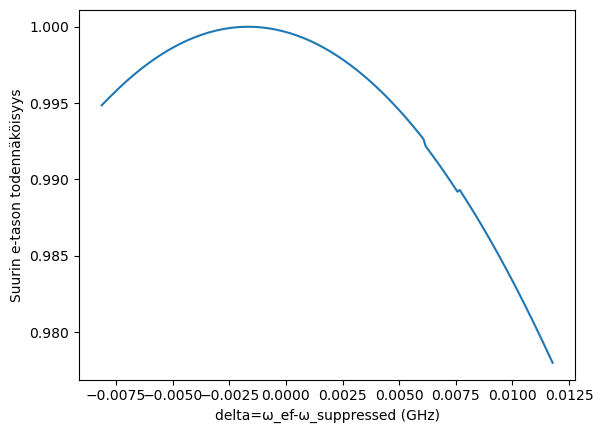

Amplitudi (GHz): 0.09122236286767381
AC-stark siirtymä (GHz): -0.0016292490903067505
E-tason suurin todennäköisyys: 0.9999999029543819
Pulssin pituus (ns): 38.350417866236185
Rabi-taajuus (fourier):  0.013553528975722309


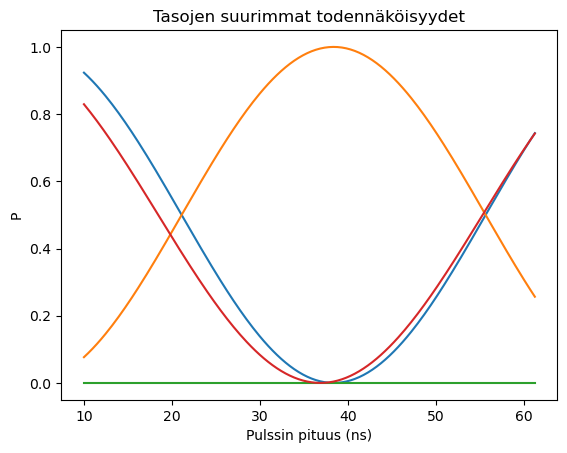

---------------------------------------------


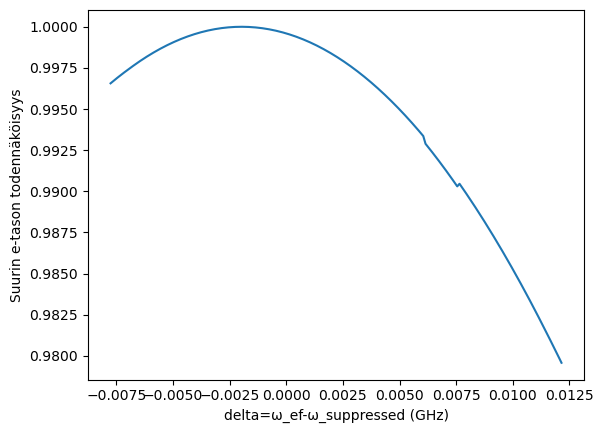

Amplitudi (GHz): 0.0999421475535544
AC-stark siirtymä (GHz): -0.0019529153066442408
E-tason suurin todennäköisyys: 0.9999994718561114
Pulssin pituus (ns): 35.39243585891118
Rabi-taajuus (fourier):  0.014850566219974087


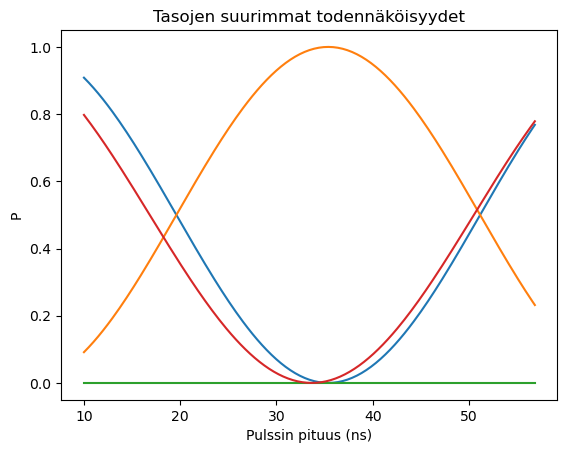

---------------------------------------------


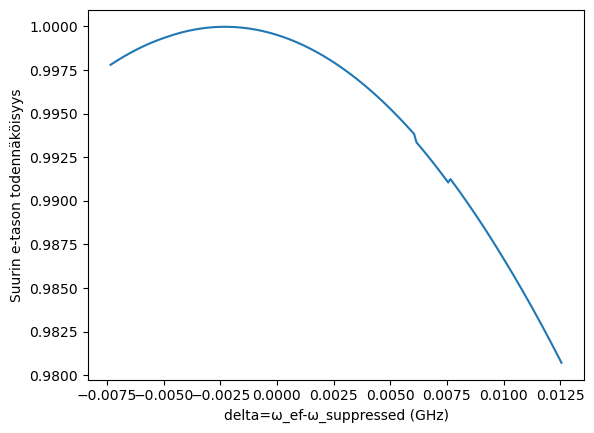

Amplitudi (GHz): 0.10866193223943496
AC-stark siirtymä (GHz): -0.002342000966450234
E-tason suurin todennäköisyys: 0.9999992188545264
Pulssin pituus (ns): 32.92750084112639
Rabi-taajuus (fourier):  0.0161420404424378


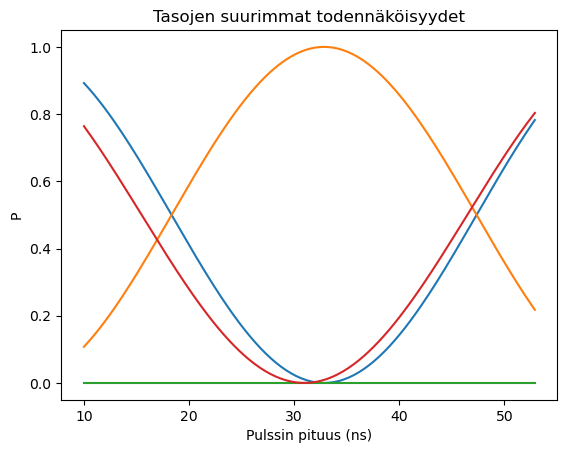

---------------------------------------------


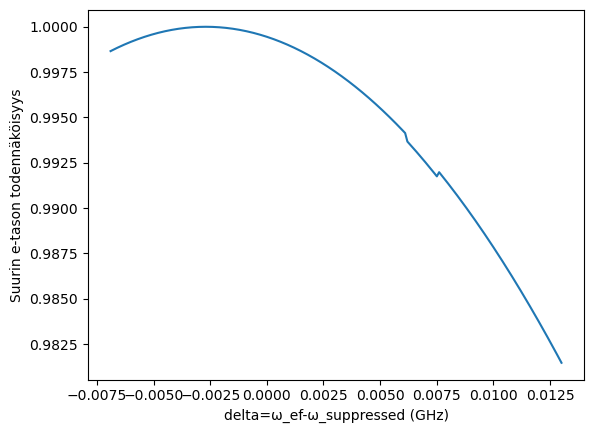

Amplitudi (GHz): 0.11738171692531556
AC-stark siirtymä (GHz): -0.002696506069724724
E-tason suurin todennäköisyys: 0.9999982449979885
Pulssin pituus (ns): 30.708998492193537
Rabi-taajuus (fourier):  0.017440696676640867


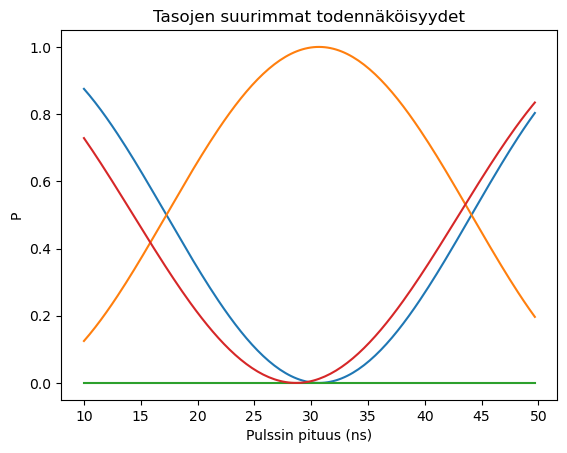

---------------------------------------------


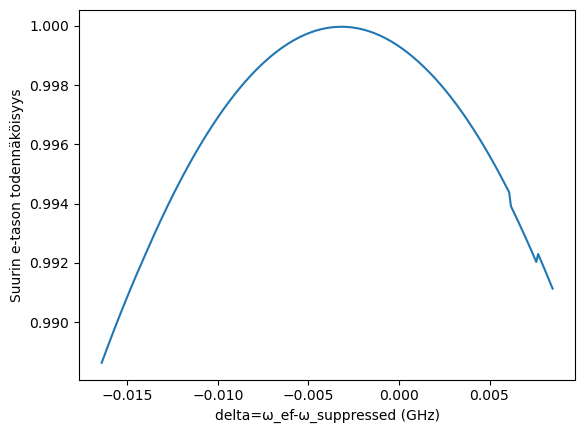

Amplitudi (GHz): 0.12610150161119615
AC-stark siirtymä (GHz): -0.0032164306164677143
E-tason suurin todennäköisyys: 0.9999992534120551
Pulssin pituus (ns): 28.737095167136232
Rabi-taajuus (fourier):  0.018741171583920743


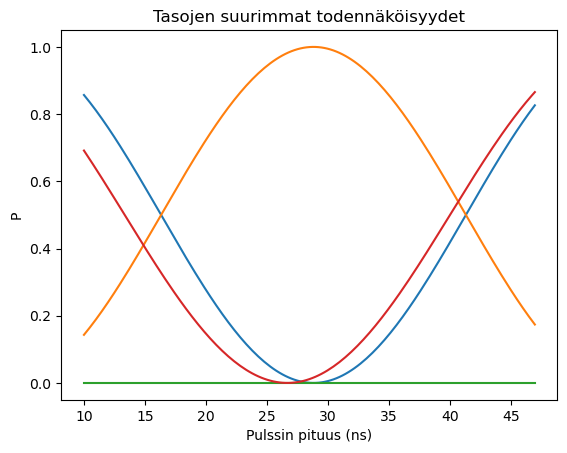

---------------------------------------------


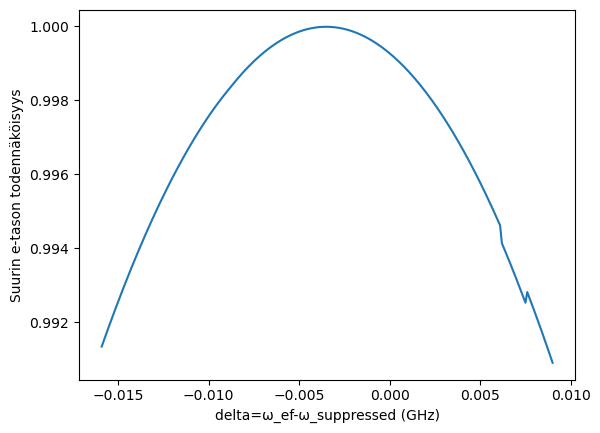

Amplitudi (GHz): 0.1348212862970767
AC-stark siirtymä (GHz): -0.0035017746066792078
E-tason suurin todennäköisyys: 0.9999958842946485
Pulssin pituus (ns): 27.258044039411626
Rabi-taajuus (fourier):  0.020037090368591505


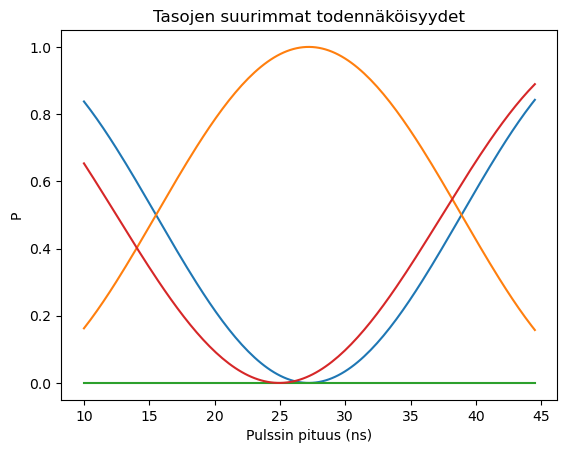

---------------------------------------------


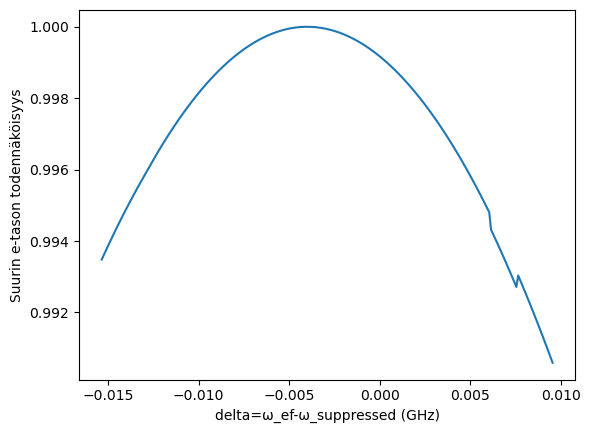

Amplitudi (GHz): 0.14354107098295732
AC-stark siirtymä (GHz): -0.004052538040359198
E-tason suurin todennäköisyys: 0.9999997408832767
Pulssin pituus (ns): 25.77912412746155
Rabi-taajuus (fourier):  0.021331287344277725


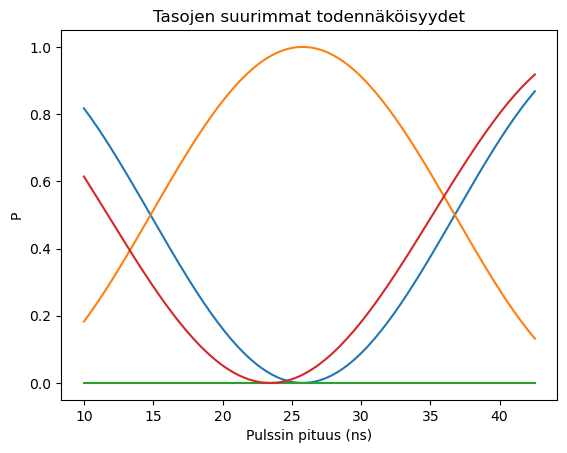

---------------------------------------------


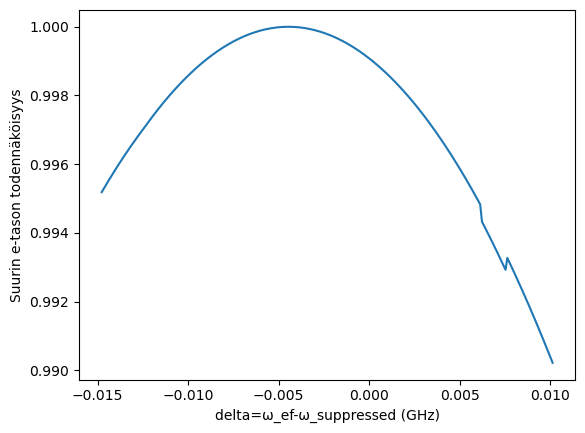

Amplitudi (GHz): 0.1522608556688379
AC-stark siirtymä (GHz): -0.00446872091750769
E-tason suurin todennäköisyys: 0.9999972697208404
Pulssin pituus (ns): 24.546617612796233
Rabi-taajuus (fourier):  0.022622693061592515


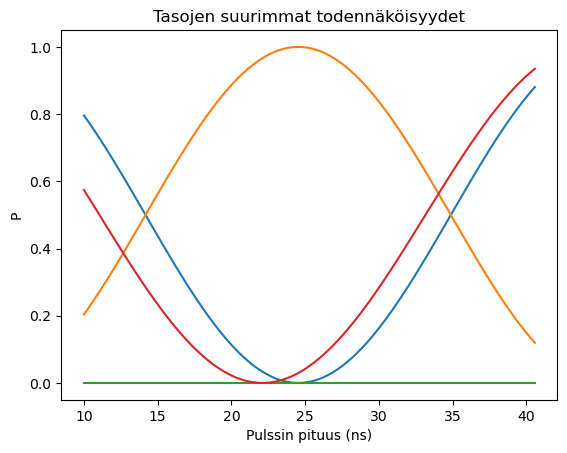

---------------------------------------------


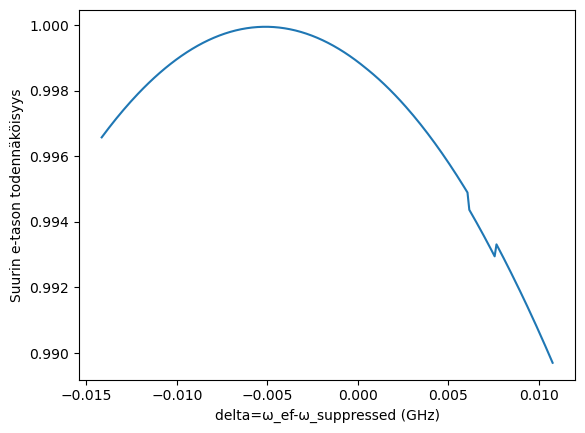

Amplitudi (GHz): 0.16098064035471846
AC-stark siirtymä (GHz): -0.005150323238124684
E-tason suurin todennäköisyys: 0.9999970361271616
Pulssin pituus (ns): 23.31420951210697
Rabi-taajuus (fourier):  0.023918045854801055


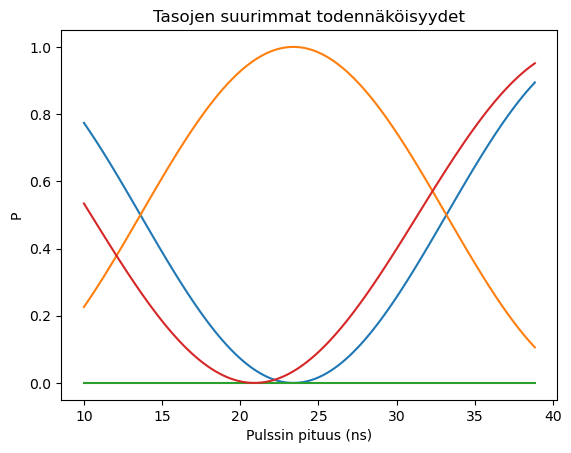

---------------------------------------------


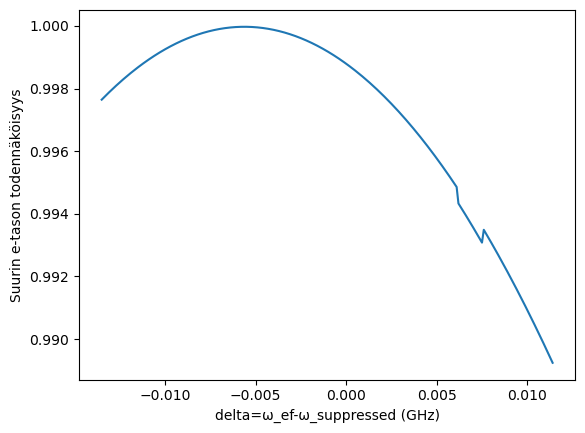

Amplitudi (GHz): 0.16970042504059907
AC-stark siirtymä (GHz): -0.005597345002210174
E-tason suurin todennäköisyys: 0.9999996077355304
Pulssin pituus (ns): 22.32818802722152
Rabi-taajuus (fourier):  0.025213341393947396


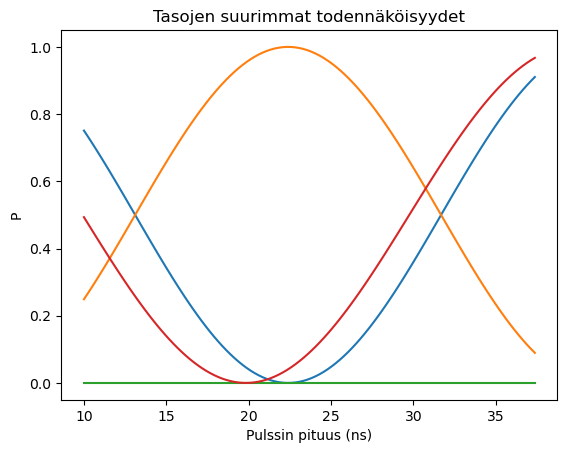

---------------------------------------------


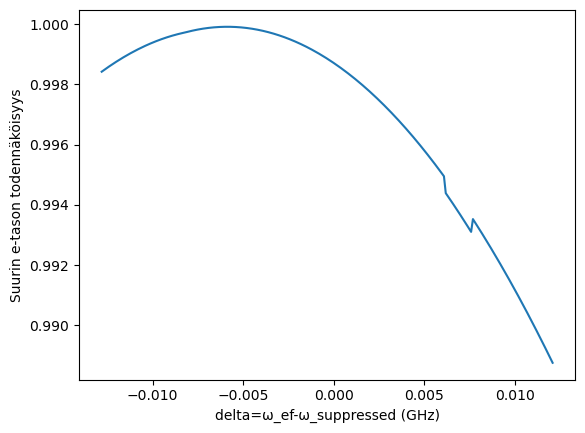

Amplitudi (GHz): 0.17842020972647968
AC-stark siirtymä (GHz): -0.0059097862097641654
E-tason suurin todennäköisyys: 0.9999952020383582
Pulssin pituus (ns): 21.588638831203568
Rabi-taajuus (fourier):  0.026507819163068668


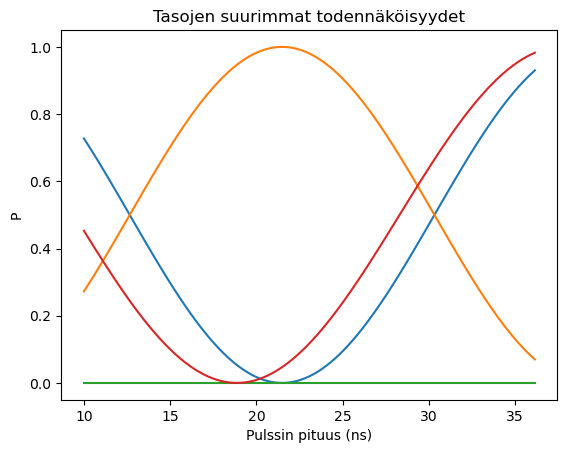

---------------------------------------------


In [6]:
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals = [] #Ajavan amplitudin arvot

#Määritellään rajat amplitudille sekä simulaatioiden määrä
min_range = 0.0005
max_range = 0.0070
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)

    f_d = qubit.frequency

    f_rabi=4*A/3 #Arvaus Rabi-taajuudelle
    AC_stark=0.2274*A**2- 0.0003122*A + 6.917e-06 #Arvaus AC-stark siirtymälle

    if i<13:
        params=find_params(f_d, A, evolution_eigenbasis,f_rabi,AC_stark,[-100,100],10000)
    else:
        params=find_params(f_d, A, evolution_eigenbasis,f_rabi,AC_stark,[-200,50],10000)

    deltas.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])
    
    f_d_opt = f_d+deltas[-1]

    m=10
    vals = sim_pulse(f_d_opt,f_ef,A,evolution_eigenbasis,dim,(f_rabi)/m,t_ramp=5,p=1)

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])

    max_vals.append([vals[0],vals[1]])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])
    
    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    #Taajuusavaruus
    freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(0.012744300694748545), np.float64(0.02146408538062913), np.float64(0.030183870066509716), np.float64(0.0389036547523903), np.float64(0.04762343943827089), np.float64(0.05634322412415147), np.float64(0.06506300881003205), np.float64(0.07378279349591264), np.float64(0.08250257818179323), np.float64(0.09122236286767381), np.float64(0.0999421475535544), np.float64(0.10866193223943496), np.float64(0.11738171692531556), np.float64(0.12610150161119615), np.float64(0.1348212862970767), np.float64(0.14354107098295732), np.float64(0.1522608556688379), np.float64(0.16098064035471846), np.float64(0.16970042504059907), np.float64(0.17842020972647968)]


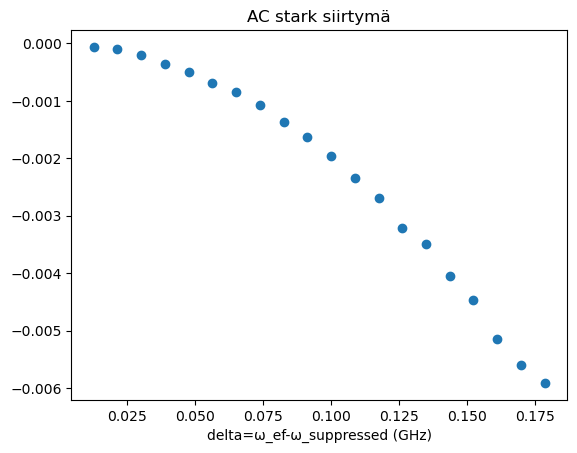

[np.float64(-6.012809935183704e-05), np.float64(-9.501932447282692e-05), np.float64(-0.00019532999306231692), np.float64(-0.00036106010512030706), np.float64(-0.0004922096606467974), np.float64(-0.0006887786596417877), np.float64(-0.0008507671021052784), np.float64(-0.0010781749880372689), np.float64(-0.0013710023174377593), np.float64(-0.0016292490903067505), np.float64(-0.0019529153066442408), np.float64(-0.002342000966450234), np.float64(-0.002696506069724724), np.float64(-0.0032164306164677143), np.float64(-0.0035017746066792078), np.float64(-0.004052538040359198), np.float64(-0.00446872091750769), np.float64(-0.005150323238124684), np.float64(-0.005597345002210174), np.float64(-0.0059097862097641654)]


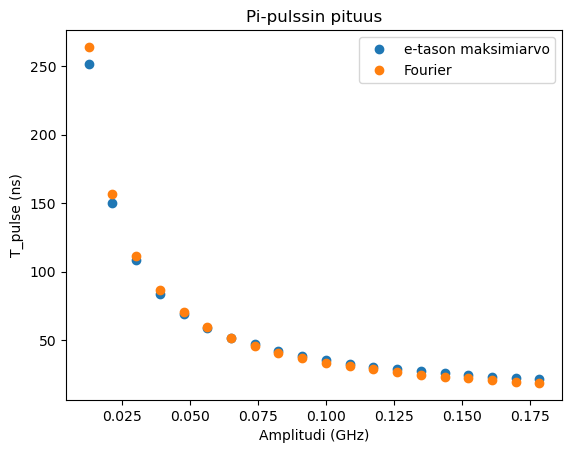

[np.float64(251.57999227525542), np.float64(150.51100417886548), np.float64(108.60460151978367), np.float64(83.95393200134825), np.float64(69.16345002618107), np.float64(59.30325525761555), np.float64(51.908033315501754), np.float64(46.97800638158603), np.float64(42.047973731355775), np.float64(38.350417866236185), np.float64(35.39243585891118), np.float64(32.92750084112639), np.float64(30.708998492193537), np.float64(28.737095167136232), np.float64(27.258044039411626), np.float64(25.77912412746155), np.float64(24.546617612796233), np.float64(23.31420951210697), np.float64(22.32818802722152), np.float64(21.588638831203568)]


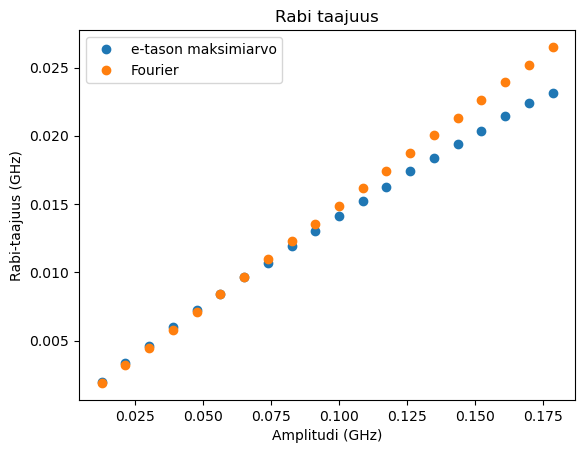

[np.float64(0.0018932189704428453), np.float64(0.0031884518825393707), np.float64(0.004483852946679996), np.float64(0.005779779375932932), np.float64(0.007074217728514737), np.float64(0.008371371157949052), np.float64(0.009664911674245711), np.float64(0.010963419747996101), np.float64(0.012260332863942692), np.float64(0.013553528975722309), np.float64(0.014850566219974087), np.float64(0.0161420404424378), np.float64(0.017440696676640867), np.float64(0.018741171583920743), np.float64(0.020037090368591505), np.float64(0.021331287344277725), np.float64(0.022622693061592515), np.float64(0.023918045854801055), np.float64(0.025213341393947396), np.float64(0.026507819163068668)]


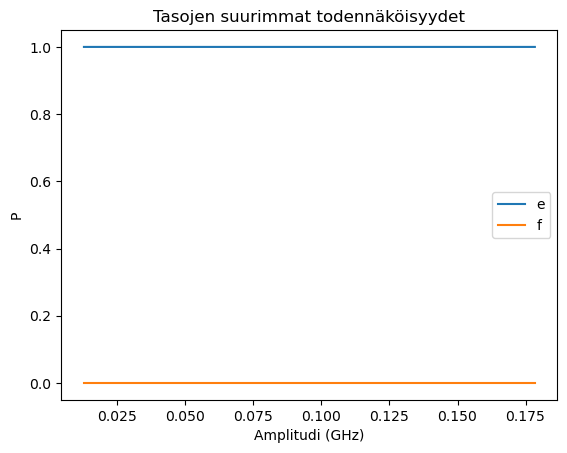

[np.float64(0.9999953223737541), np.float64(0.9999999886742346), np.float64(0.9999997221285672), np.float64(0.9999976622456761), np.float64(0.9999993825431176), np.float64(0.9999990112597176), np.float64(0.9999998613906432), np.float64(0.9999996801587152), np.float64(0.9999999218463151), np.float64(0.9999999029543819), np.float64(0.9999994718561114), np.float64(0.9999992188545264), np.float64(0.9999982449979885), np.float64(0.9999992534120551), np.float64(0.9999958842946485), np.float64(0.9999997408832767), np.float64(0.9999972697208404), np.float64(0.9999970361271616), np.float64(0.9999996077355304), np.float64(0.9999952020383582)]
[np.float64(6.817435929818866e-12), np.float64(2.3669759074366097e-11), np.float64(5.6902811681732003e-11), np.float64(1.1426715619757785e-10), np.float64(2.0607768340139308e-10), np.float64(3.460622864923016e-10), np.float64(5.495722318017658e-10), np.float64(8.365127884262081e-10), np.float64(1.2303014847420845e-09), np.float64(1.7539209733352783e-09), np

In [7]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.xlabel("delta=ω_ef-ω_suppressed (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.plot(A_vals, 1/(2*np.array(rabis)), 'o')
plt.legend(["e-tason maksimiarvo","Fourier"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, 1/(2*np.array(pulse_lengths)), 'o')
plt.plot(A_vals, rabis, 'o')
plt.legend(["e-tason maksimiarvo","Fourier"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(A_vals, e_vals)
plt.plot(A_vals, f_vals)
plt.legend(["e","f"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)

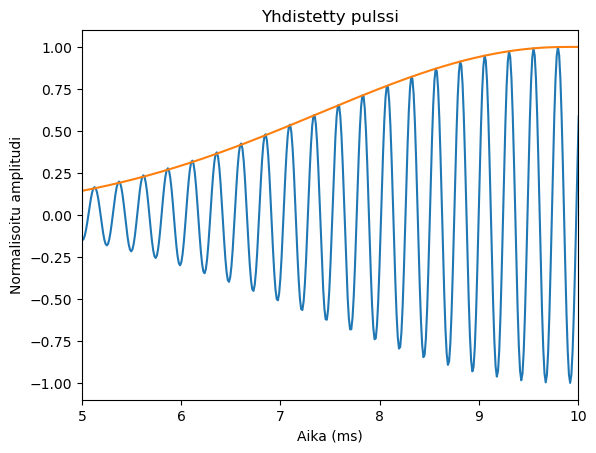

0.9989059444512229 2.5442406209086825e-08 21.585951889817178


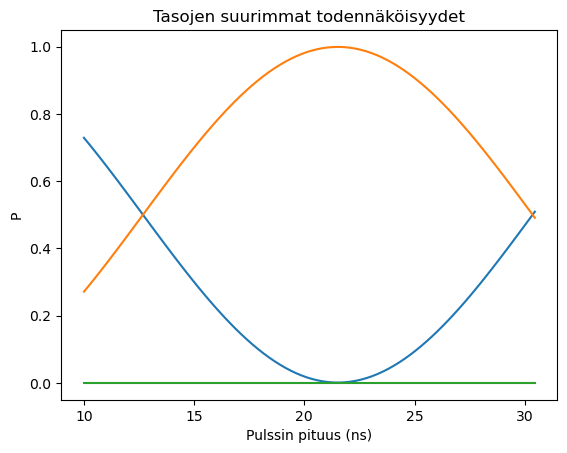

---------------------------------------------


In [8]:
A=0.17842020972626485
f_d=qubit.frequency
vals = sim_pulse(f_d,f_ef-0.09280978620978153,A,evolution_eigenbasis,dim,0.3,t_ramp=5,p=1,verbose=True)
print(vals[0],vals[1],vals[2])

g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

m=1
n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.plot(vals[4][:n_picked], g_vals[:n_picked])
plt.plot(vals[4][:n_picked], e_vals[:n_picked])
plt.plot(vals[4][:n_picked], f_vals[:n_picked])
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")